In [1]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set(style="whitegrid")


In [3]:
s3 = boto3.client("s3")

bucket_name = "housewhiz-analytics-data"

files = [
    "housing.csv",
    "hpi_master.csv",
    "Race.xlsx",
    "Resident Population by Age and Sex.xlsx",
    "Total Population by County.xlsx"
]

for file_name in files:
    s3.download_file(bucket_name, file_name, file_name)
    print(f"Downloaded {file_name}")

Downloaded housing.csv
Downloaded hpi_master.csv
Downloaded Race.xlsx
Downloaded Resident Population by Age and Sex.xlsx
Downloaded Total Population by County.xlsx


In [4]:
housing = pd.read_csv("housing.csv")
hpi = pd.read_csv("hpi_master.csv")

race = pd.read_excel("Race.xlsx")
age_sex = pd.read_excel("Resident Population by Age and Sex.xlsx")
population = pd.read_excel("Total Population by County.xlsx")

In [5]:
def explore(df, name):
    print("==============")
    print("Dataset:", name)
    print("==============")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns)
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nSummary Statistics:")
    print(df.describe(include='all'))

In [6]:
explore(housing, "Housing Data")
explore(hpi, "HPI Data")
explore(race, "Race Data")
explore(age_sex, "Age & Sex Data")
explore(population, "Population Data")

Dataset: Housing Data

Shape:
(20640, 10)

Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0

Summary Statistics:
           longitude      latitude  housing_median_age   total_rooms  \
count   2

In [7]:
print("\n=== KEY INSIGHTS ===")

print("""
1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data
""")


=== KEY INSIGHTS ===

1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data



In [8]:
num_cols = housing.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = housing[(housing[col] < lower) | (housing[col] > upper)].shape[0]
    
    print(col, "Outliers:", outliers)

longitude Outliers: 0
latitude Outliers: 0
housing_median_age Outliers: 0
total_rooms Outliers: 1287
total_bedrooms Outliers: 1271
population Outliers: 1196
households Outliers: 1220
median_income Outliers: 681
median_house_value Outliers: 1071


### Observations from Outlier Analysis

- Several variables (total_rooms, population, households) contain a large number of outliers.
- This is expected in real world housing data where distributions are often skewed.
- Median house value also contains outliers, which may represent high value properties or capped values.
- These outliers may impact model performance and may require transformation or normalization in later stages.

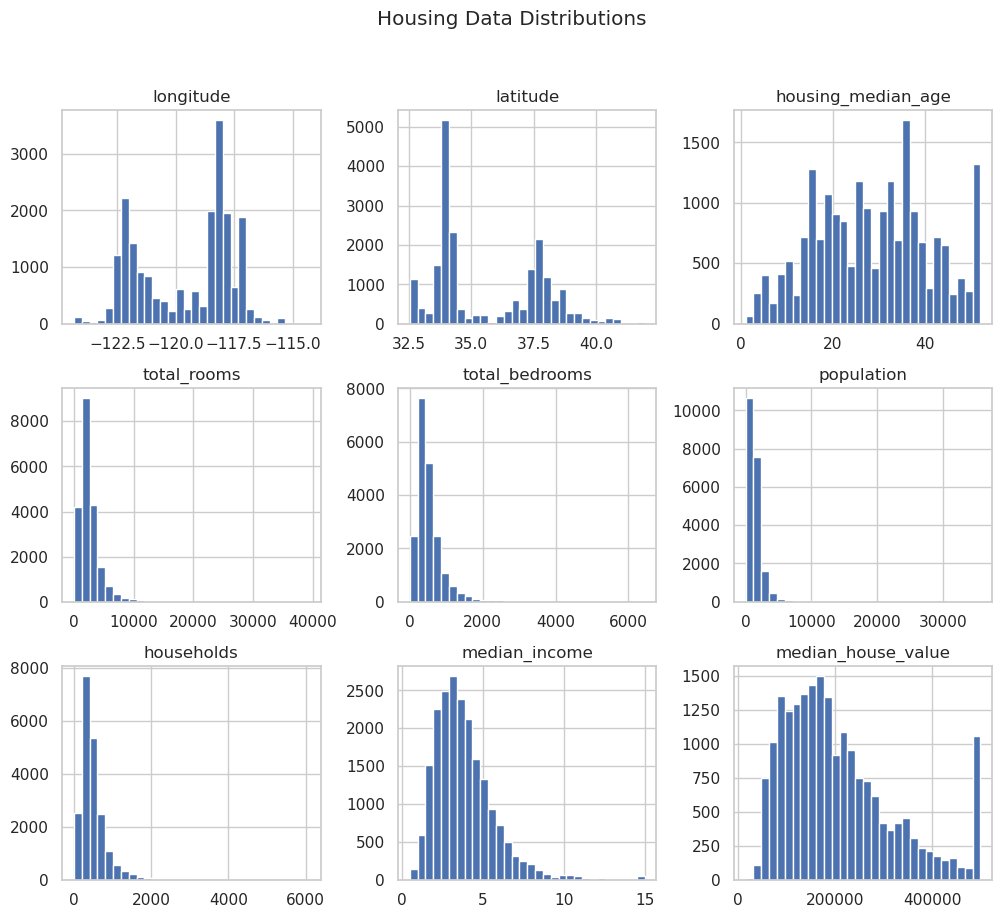

In [9]:
#Housing Histogram 
housing.hist(figsize=(12,10) , bins=30)
plt.suptitle("Housing Data Distributions")
plt.show()

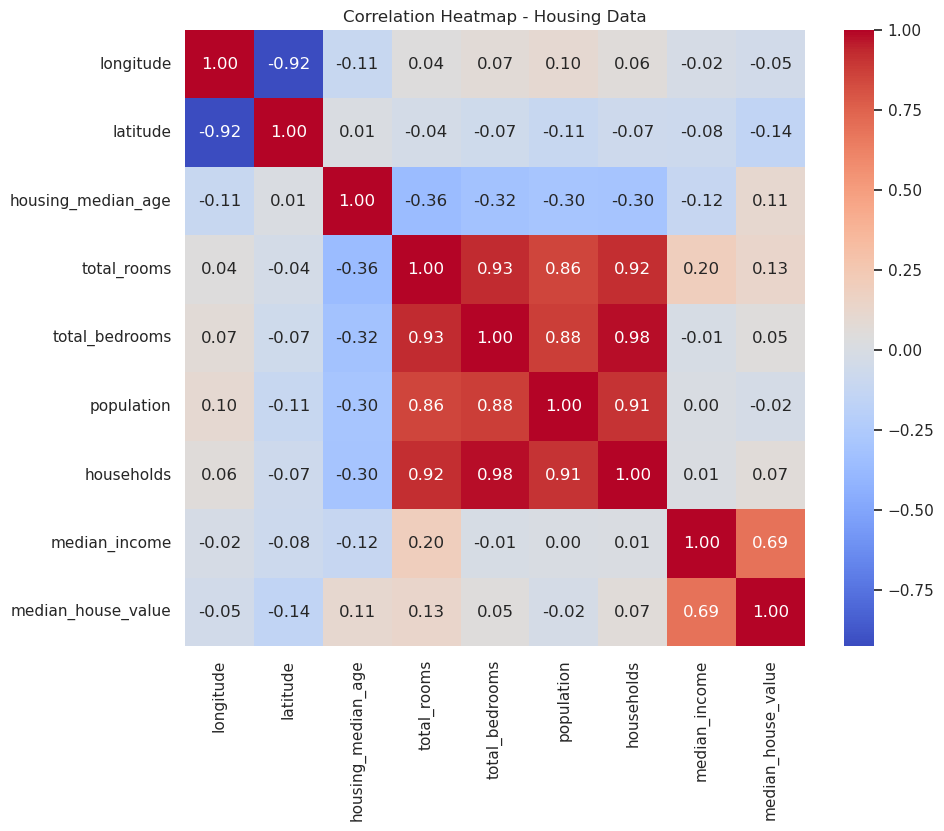

In [10]:
#Correlation Heat Map 
plt.figure(figsize=(10,8))
corr_housing = housing.corr(numeric_only = True)

sns.heatmap(corr_housing,annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap - Housing Data")
plt.show()

### Correlation Insights

- Median income shows a strong positive correlation with median house value.
- Features such as total_rooms and households show strong correlation with population related variables.
- Longitude and latitude show a strong negative linear correlations but are important for geographic patterns.

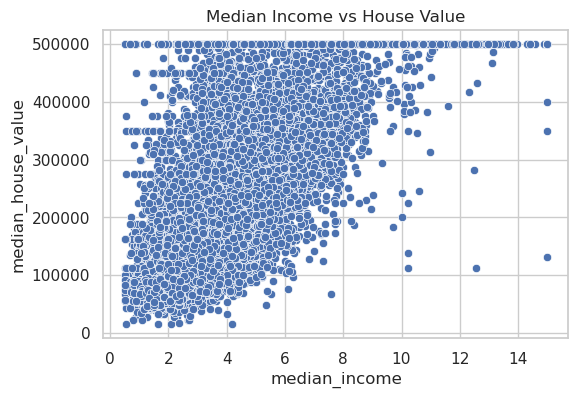

In [11]:
#Scatterplot of Median Income Vs Median House Value
plt.figure(figsize=(6,4))
sns.scatterplot(data=housing, x="median_income", y="median_house_value")
plt.title("Median Income vs House Value")
plt.show()

### Scatter Plot Observations (Median Income vs House Value)
- Strong positive relationship between median_income and median_house_value
- Higher income areas tend to have higher housing prices
- Data shows clear upward trend overall
- Noticeable clustering of values at the upper limit (~500,000)
- Indicates the target variable is capped
- Reduced variability at lower income levels
- Greater spread in house values at higher income levels
- median_income appears to be a strong predictor of housing price
- Some outliers exist at higher income levels with varying house values
- Relationship is not perfectly linear, suggesting influence from other features (location)

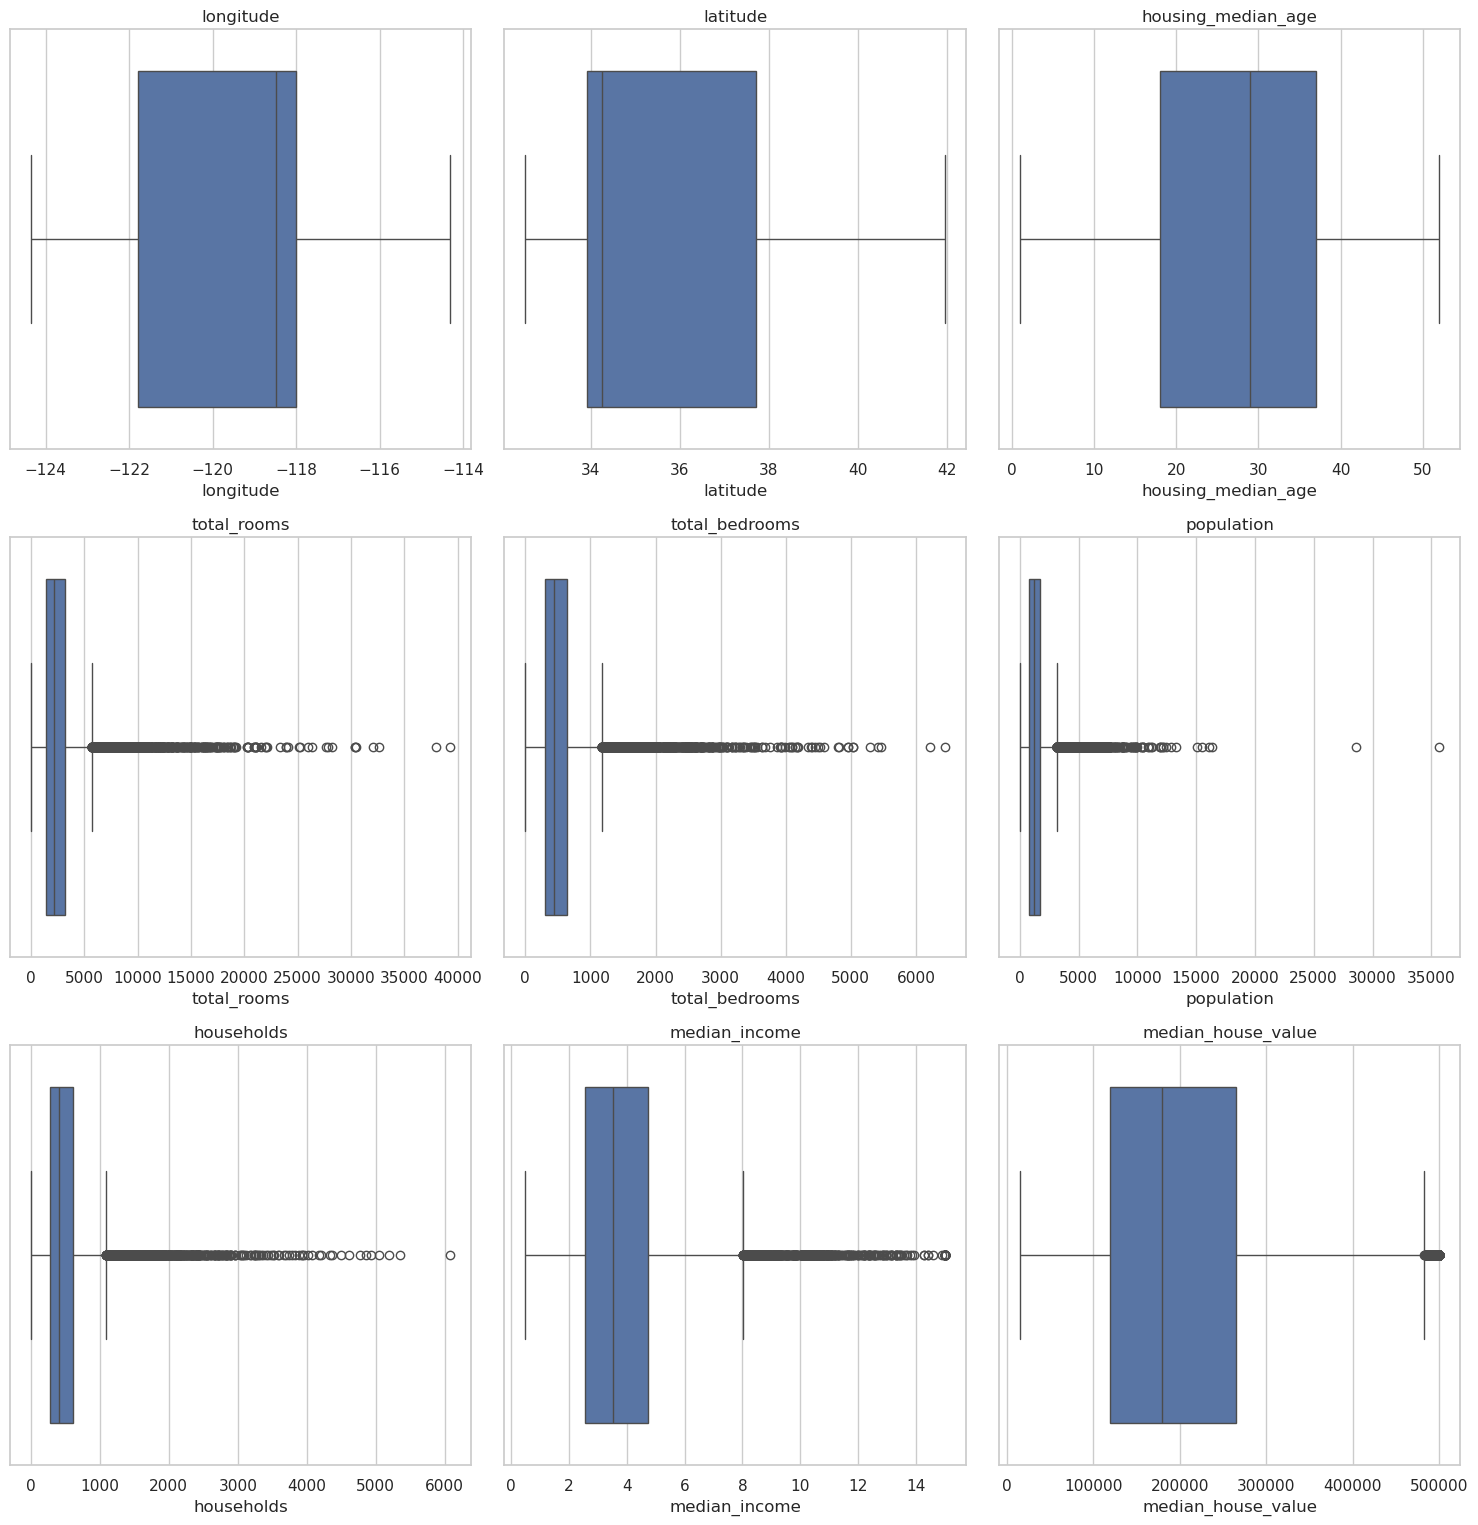

In [12]:
#Boxplot to Visualize Outlier
num_cols = housing.select_dtypes(include='number').columns

# Set grid size
cols = 3  # number of plots per row
rows = (len(num_cols) // cols) + 1

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=housing[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Data Preparation 

In [13]:
#Missing values in housing.csv file 
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())

#confirmation 
housing["total_bedrooms"].isnull().sum()


0

### Feature Selection


In [14]:
x=housing.drop("median_house_value", axis =1)
y=housing["median_house_value"]


### Handling Categorical Values 

In [15]:
x=pd.get_dummies(x, columns=["ocean_proximity"], drop_first=True)

### Feature Engineering 


In [16]:
x["rooms_per_household"] = x["total_rooms"] / x["households"]
x["bedrooms_per_room"] = x["total_bedrooms"] / x["total_rooms"]
x["population_per_household"] = x["population"] / x["households"]

### Scaling 


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

### Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

### Combine Features 

In [19]:
train_data = x_train.copy()
train_data["median_house_value"] = y_train.values

test_data = x_test.copy()
test_data["median_house_value"] = y_test.values

train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
14196,1.267645,-1.367976,0.346478,0.224718,0.214986,0.772251,0.322924,-0.321654,-0.681889,-0.015566,-0.353264,2.601007,-0.166259,-0.202590,0.059808,103000.0
8267,0.703627,-0.871699,1.617807,0.342065,0.596500,-0.098440,0.670799,-0.030620,-0.681889,-0.015566,-0.353264,2.601007,-0.386181,0.289800,-0.128306,382100.0
17445,-0.454356,-0.455012,-1.957806,-0.338639,-0.490815,-0.450778,-0.427755,0.150349,-0.681889,-0.015566,-0.353264,2.601007,0.087641,-0.602454,-0.033453,172600.0
14265,1.227714,-1.377340,0.584852,-0.556832,-0.404974,-0.006602,-0.378059,-1.014947,-0.681889,-0.015566,-0.353264,2.601007,-0.576442,0.681641,0.088940,93400.0
2271,-0.114948,0.537543,1.141059,-0.116322,-0.252369,-0.486983,-0.312669,-0.166583,1.466514,-0.015566,-0.353264,-0.384466,0.339282,-0.503532,-0.074203,96500.0


### Save Locally as CSV


In [20]:
train_data.to_csv("train.csv", index=False)
test_data.to_csv("test.csv", index=False)

print("Train and test datasets saved locally.")

Train and test datasets saved locally.


### Upload to S3 bucket 

In [24]:
bucket_name = "ads508group6finalteamproject"

s3.upload_file("train.csv", bucket_name, "processed/train/train.csv")
s3.upload_file("test.csv", bucket_name, "processed/test/test.csv")

print("Train and test datasets uploaded to S3.")

Train and test datasets uploaded to S3.


In [25]:
# s3.list_objects_v2(Bucket=bucket_name, Prefix="processed/") 

In [26]:
# -------------------------------
# Connect to S3
# -------------------------------
# These are the prepared files created in the previous module.
# We are not repeating cleaning, encoding, scaling, or splitting here.

s3 = boto3.client("s3")
bucket_name = "housewhiz-analytics-data"

train_key = "processed/train/train.csv"
test_key = "processed/test/test.csv"

# Load train and test data directly from S3
train_obj = s3.get_object(Bucket=bucket_name, Key=train_key)
test_obj = s3.get_object(Bucket=bucket_name, Key=test_key)

train_data = pd.read_csv(train_obj["Body"])
test_data = pd.read_csv(test_obj["Body"])

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

train_data.head()

Train shape: (16512, 16)
Test shape: (4128, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
0,1.267645,-1.367976,0.346478,0.224718,0.214986,0.772251,0.322924,-0.321654,-0.681889,-0.015566,-0.353264,2.601007,-0.166259,-0.202590,0.059808,103000.0
1,0.703627,-0.871699,1.617807,0.342065,0.596500,-0.098440,0.670799,-0.030620,-0.681889,-0.015566,-0.353264,2.601007,-0.386181,0.289800,-0.128306,382100.0
2,-0.454356,-0.455012,-1.957806,-0.338639,-0.490815,-0.450778,-0.427755,0.150349,-0.681889,-0.015566,-0.353264,2.601007,0.087641,-0.602454,-0.033453,172600.0
3,1.227714,-1.377340,0.584852,-0.556832,-0.404974,-0.006602,-0.378059,-1.014947,-0.681889,-0.015566,-0.353264,2.601007,-0.576442,0.681641,0.088940,93400.0
4,-0.114948,0.537543,1.141059,-0.116322,-0.252369,-0.486983,-0.312669,-0.166583,1.466514,-0.015566,-0.353264,-0.384466,0.339282,-0.503532,-0.074203,96500.0


In [27]:
# -------------------------------
# Split X and y
# -------------------------------
# The target is median_house_value.
# Everything else is already prepared feature data.

X_train = train_data.drop("median_house_value", axis=1)
y_train = train_data["median_house_value"]

X_test = test_data.drop("median_house_value", axis=1)
y_test = test_data["median_house_value"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 15)
X_test: (4128, 15)


In [28]:
# -------------------------------
# Train Random Forest
# -------------------------------
# Random Forest is a good fit for housing price prediction
# because it handles nonlinear relationships and works well
# with tabular data.

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model training complete.")

Random Forest model training complete.


In [29]:
# -------------------------------
# Evaluate Model
# -------------------------------
# We use MAE, RMSE, and R2 because this is a regression problem.

predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Evaluation Results")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

Evaluation Results
------------------
MAE : 35617.43
RMSE: 53474.76
R2  : 0.7818


In [30]:
# -------------------------------
# Compare Actual vs Predicted
# -------------------------------

results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

results

,Actual,Predicted
0,47700.0,60024.328252
1,45800.0,168697.752653
2,500001.0,449294.241304
3,218600.0,251424.530826
4,278000.0,252054.268245
5,158700.0,183044.108949
6,198200.0,249938.961275
7,157500.0,169533.382925
8,340000.0,257048.946840
9,446600.0,480976.137944


In [32]:
# -------------------------------
# Save Model Locally
# -------------------------------
import joblib

model_filename = "random_forest_model.joblib"
joblib.dump(rf_model, model_filename)

print(f"Model saved locally as {model_filename}")

Model saved locally as random_forest_model.joblib


In [35]:
bucket_name = "ads508group6finalteamproject"

# Save model locally
model_filename = "random_forest_model.joblib"
joblib.dump(rf_model, model_filename)

# Upload model to S3
model_key = "models/random_forest_model.joblib"
s3.upload_file(model_filename, bucket_name, model_key)

print(f"Model uploaded to s3://{bucket_name}/{model_key}")

Model uploaded to s3://ads508group6finalteamproject/models/random_forest_model.joblib


In [36]:
# -------------------------------
# Save Evaluation Metrics
# -------------------------------

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

metrics_file = "training_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

metrics_s3_key = "models/training_metrics.csv"
s3.upload_file(metrics_file, bucket_name, metrics_s3_key)

print(f"Metrics uploaded to s3://{bucket_name}/{metrics_s3_key}")

Metrics uploaded to s3://ads508group6finalteamproject/models/training_metrics.csv


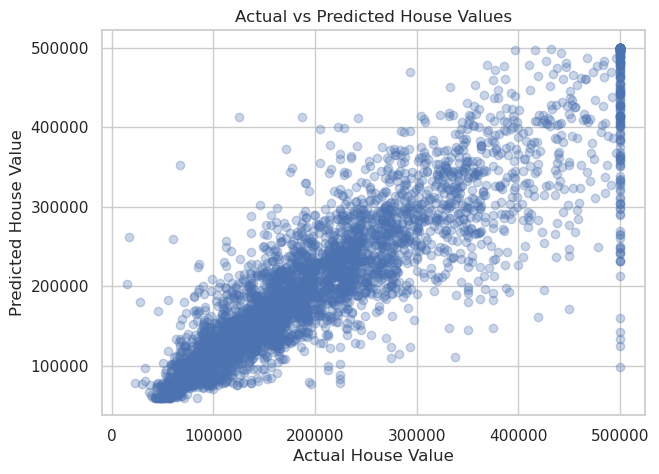

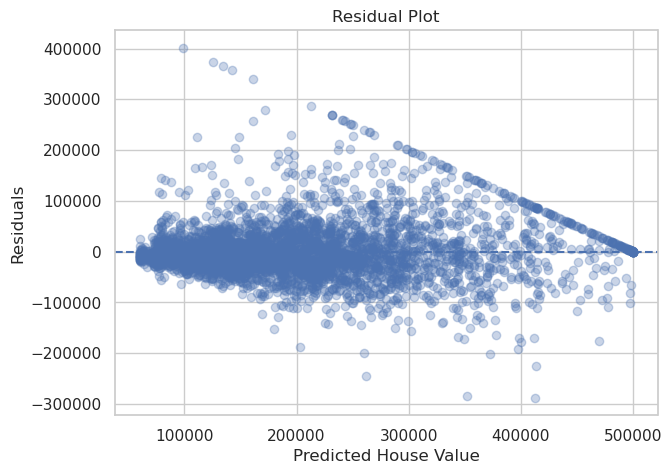

In [37]:
# Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.show()

# Residuals
residuals = y_test - predictions

plt.figure(figsize=(7,5))
plt.scatter(predictions, residuals, alpha=0.3)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()